## Improved Prediction of Parkinson’s Disease Medication Needs Through Nested Conformal Prediction

### Two-Stage Approach with Venn-Abers Calibration + Conformal Prediction
We use Venn Abers (VA) uncertainty to inform Stage 2 prediction intervals, not to filter patients.
Hypothesis:
- Low uncertainty → Stage 2 provides narrow intervals (confident)
- High uncertainty → Stage 2 provides wide intervals (cautious)

This is the nested effect: Stage 1 confidence propagates to Stage 2.

Differences from previous approach:
- Paper: Filters by predicted probability of medication changes
- This: Uses VA uncertainty to inform interval width

In [1]:
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from venn_abers import VennAbers

from mapie.regression import MapieRegressor
from mapie.metrics import regression_coverage_score, regression_mean_width_score
from mapie.subsample import Subsample

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore', message='WARNING: The predictions are ill-sorted')

In [2]:
color_azure = '#0097B2'
color_orange = '#F35000'
color_blue = '#263985' 
color_red = '#B00000'
color_yellow = '#FCD116'
color_dark_grey = '#A9A9A9'
color_purple = '#9740A6'
color_light_purple = '#AA8ED6'
color_gold = '#FFD700'
color_gold_2 = '#FFA500' 
color_palette = [color_azure, color_orange, color_blue, color_red, color_yellow, color_dark_grey, color_purple, color_light_purple, color_gold]
color_palette_2 = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#4B3F72', '#73956F']

## Data Loading and Preprocessing

In [3]:
path = 'data/data_1Y.csv'
data = pd.read_csv(path)

# Continous Outcome (LEDD Change)
normalized_pctg_change = data['normalized_percent_change']  # Save for Stage 2
data.drop(columns=['normalized_percent_change'], inplace=True)

# Prepare features
xgboost_df = data.copy()

# One-hot encoding
demographic_vars = ['gender_source_value', 'race_source_value', 'ethnicity_source_value']
xgboost_df = pd.get_dummies(xgboost_df, columns=demographic_vars)

# Scaling
scaler = MinMaxScaler()
numeric_vars = ['mean_led_per_visit', 'age', 'length_of_stay', 'days_since_last_visit', 'days_to_diagnosis']
for var in numeric_vars:
    xgboost_df[var] = scaler.fit_transform(xgboost_df[[var]])

# Reordering columns
prediction_to_last = xgboost_df.pop('prediction')
xgboost_df['prediction'] = prediction_to_last

# Features and targets
X = xgboost_df.iloc[:, :-1]
y_binary = xgboost_df.iloc[:, -1]  # Binary: medication change needed
y_continuous = normalized_pctg_change  # Continuous: percent change in LEDD

# Stage 1: Binary Classification with Venn-Abers
Get VA uncertainty estimates for ALL patients in Stage 1 binary prediction. This will inform Stage 2 interval widths instead of filtering patients!

In [4]:
print("\n" + "="*80)
print("STAGE 1: Binary Classification + Venn-Abers Calibration")
print("="*80)
random_state = 21

# Split for Stage 1: Train on 80%, use 20% for VA calibration
X_train_stage1, X_test_stage1, y_train_stage1, y_test_stage1 = train_test_split(
    X, y_binary, test_size=0.2, random_state=random_state
)

print(f"\nStage 1 Split:")
print(f"  Training (for binary):  {len(X_train_stage1):4d} ({len(X_train_stage1)/len(X)*100:.1f}%)")
print(f"  Test (for VA calib):    {len(X_test_stage1):4d} ({len(X_test_stage1)/len(X)*100:.1f}%)")

# XGBoost parameters
best_params = {
    "eval_metric": "auc",
    "objective": "binary:logistic",
    'sampling_method': 'gradient_based',
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'tree_method': 'hist',
    'device': "cuda",
}
# Train XGBoost binary classifier on FULL training set
d_train = xgb.DMatrix(X_train_stage1, label=y_train_stage1)
d_test = xgb.DMatrix(X_test_stage1, label=y_test_stage1)

print("\nTraining Stage 1 XGBoost classifier...")
model_stage1 = xgb.train(
    best_params, 
    d_train,
    num_boost_round=700,
    evals=[(d_test, "validation")],
    verbose_eval=100,
    early_stopping_rounds=10
)

# Get predictions on held-out test set for VA calibration
print("\nGetting predictions for Venn-Abers calibration...")
p_test_uncalibrated = model_stage1.predict(
    d_test, 
    iteration_range=(0, model_stage1.best_iteration + 1)
)

# Convert to 2D for VennAbers
p_test_2d = np.column_stack([1 - p_test_uncalibrated, p_test_uncalibrated])

# Fit Venn-Abers calibrator
print("Calibrating with Venn-Abers...")
va = VennAbers()
va.fit(p_test_2d, y_test_stage1.values)

# Get VA predictions for ALL patients
print("\nGetting VA predictions for ALL patients...")
d_all = xgb.DMatrix(X)
p_all_uncalibrated = model_stage1.predict(
    d_all, 
    iteration_range=(0, model_stage1.best_iteration + 1)
)

# Convert to 2D and get VA intervals
p_all_2d = np.column_stack([1 - p_all_uncalibrated, p_all_uncalibrated])
p_lower_all_2d, p_upper_all_2d = va.predict_proba(p_all_2d)

# Extract predictions for class 1 (needs medication change)
p_lower_all = p_lower_all_2d[:, 1]
p_upper_all = p_upper_all_2d[:, 1]
p_mid_all = (p_lower_all + p_upper_all) / 2
va_uncertainty_all = p_upper_all - p_lower_all

print(f"\nVA predictions computed for {len(X)} patients")
print(f"VA Uncertainty Statistics (ALL patients):")
print(f"  Mean:   {va_uncertainty_all.mean():.4f}")
print(f"  Std:    {va_uncertainty_all.std():.4f}")
print(f"  Min:    {va_uncertainty_all.min():.4f}")
print(f"  Max:    {va_uncertainty_all.max():.4f}")
print(f"  Median: {np.median(va_uncertainty_all):.4f}")


STAGE 1: Binary Classification + Venn-Abers Calibration

Stage 1 Split:
  Training (for binary):  4884 (80.0%)
  Test (for VA calib):    1221 (20.0%)

Training Stage 1 XGBoost classifier...
[0]	validation-auc:0.86294
[100]	validation-auc:0.95154
[200]	validation-auc:0.96313
[241]	validation-auc:0.96421

Getting predictions for Venn-Abers calibration...
Calibrating with Venn-Abers...

Getting VA predictions for ALL patients...

VA predictions computed for 6105 patients
VA Uncertainty Statistics (ALL patients):
  Mean:   0.0069
  Std:    0.0163
  Min:    0.0000
  Max:    0.1537
  Median: 0.0003


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3: SELECT STAGE 2 PATIENTS (NO PROBABILITY FILTERING!)
# ═══════════════════════════════════════════════════════════════════════════
"""
CRITICAL CHANGE:
We do NOT filter by probability threshold!
We only use patients who actually need medication change (y_binary == 1)

This gives us:
- Full VA uncertainty range [0.001, 0.500]
- Large sample size (~3000 patients)
- True cascade effect visible
"""

print("\n" + "="*80)
print("SELECTING STAGE 2 PATIENTS - NO PROBABILITY FILTERING")
print("="*80)

# Use only patients who actually need medication change
# (This is the TRUE POSITIVE class from Stage 1)
mask = (y_binary == 1)

X_stage2 = X[mask]
y_stage2 = y_continuous[mask]
va_uncertainty_stage2 = va_uncertainty_all[mask]
p_lower_stage2 = p_lower_all[mask]
p_upper_stage2 = p_upper_all[mask]

print(f"\nSelection criterion: y_binary == 1 (actually needs medication change)")
print(f"Patients selected: {len(X_stage2)} / {len(X)} ({len(X_stage2)/len(X)*100:.1f}%)")
print(f"\nVA Uncertainty in STAGE 2 population:")
print(f"  Mean:   {va_uncertainty_stage2.mean():.4f}")
print(f"  Std:    {va_uncertainty_stage2.std():.4f}")
print(f"  Min:    {va_uncertainty_stage2.min():.4f}")
print(f"  Max:    {va_uncertainty_stage2.max():.4f}")
print(f"  Range:  {va_uncertainty_stage2.max() - va_uncertainty_stage2.min():.4f}")

# Flag high uncertainty patients (for analysis)
HIGH_UNCERTAINTY_THRESHOLD = np.percentile(va_uncertainty_stage2, 75)  # Top 25%
is_high_uncertainty = va_uncertainty_stage2 > HIGH_UNCERTAINTY_THRESHOLD

print(f"\nHigh Uncertainty Flagging:")
print(f"  Threshold (75th percentile): {HIGH_UNCERTAINTY_THRESHOLD:.4f}")
print(f"  Patients flagged as HIGH uncertainty: {is_high_uncertainty.sum()} ({is_high_uncertainty.sum()/len(X_stage2)*100:.1f}%)")
print(f"  → These will get WIDER intervals to maintain coverage")



SELECTING STAGE 2 PATIENTS - NO PROBABILITY FILTERING

Selection criterion: y_binary == 1 (actually needs medication change)
Patients selected: 1533 / 6105 (25.1%)

VA Uncertainty in STAGE 2 population:
  Mean:   0.0219
  Std:    0.0256
  Min:    0.0002
  Max:    0.1537
  Range:  0.1535

High Uncertainty Flagging:
  Threshold (75th percentile): 0.0294
  Patients flagged as HIGH uncertainty: 372 (24.3%)
  → These will get WIDER intervals to maintain coverage


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4: STAGE 2 SPLIT
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("STAGE 2: Train/Test Split")
print("="*80)

X_train_2, X_test_2, y_train_2, y_test_2, \
va_unc_train_2, va_unc_test_2, \
p_lower_train_2, p_lower_test_2 = train_test_split(
    X_stage2, y_stage2,
    va_uncertainty_stage2,
    p_lower_stage2,
    test_size=0.2, random_state=random_state
)

print(f"Training: {len(X_train_2)} patients")
print(f"Test:     {len(X_test_2)} patients")
print(f"Mean LEDD change (train): {y_train_2.mean():.3f}")
print(f"Mean LEDD change (test):  {y_test_2.mean():.3f}")

# Train base regression model
regression_params = {
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'n_estimators': 700,
    "eval_metric": 'rmse',
    'objective': 'reg:squarederror',
    'sampling_method': 'gradient_based',
    'tree_method': 'hist',
    'device': "cuda"
}

print("\nTraining base regression model...")
xgb_model_base = xgb.XGBRegressor(**regression_params, random_state=random_state)
xgb_model_base.fit(X_train_2, y_train_2)

y_pred_base = xgb_model_base.predict(X_test_2)
rmse = np.sqrt(mean_squared_error(y_test_2, y_pred_base))
mae = mean_absolute_error(y_test_2, y_pred_base)
r2 = r2_score(y_test_2, y_pred_base)

print(f"Base Model Performance:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")


STAGE 2: Train/Test Split
Training: 1226 patients
Test:     307 patients
Mean LEDD change (train): 0.017
Mean LEDD change (test):  0.036

Training base regression model...
Base Model Performance:
  RMSE: 0.0995
  MAE:  0.0380
  R²:   0.9801


/home/rdiazrincon/.local/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [12:35:59] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5: CONFORMAL PREDICTION STRATEGIES
# ═══════════════════════════════════════════════════════════════════════════

STRATEGIES = {
    "naive": {"method": "naive"},
    "cv_plus": {"method": "plus", "cv": 10},
    "jackknife_plus_ab": {"method": "plus", "cv": Subsample(n_resamplings=50)},
}
alpha = 0.2  # Target: 80% coverage

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: BASELINE (Ignores VA Uncertainty)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("EXPERIMENT 1: BASELINE (Ignores VA Uncertainty)")
print("="*80)
print("Standard conformal prediction - uniform intervals for all patients")
print("-"*80)

results_baseline = {}

for strategy, params in STRATEGIES.items():
    # Standard MAPIE conformal prediction
    mapie = MapieRegressor(
        xgb_model_base, 
        test_size=0.2, 
        **params, 
        random_state=random_state
    )
    mapie.fit(X_train_2, y_train_2)
    y_pred, y_pis = mapie.predict(X_test_2, alpha=alpha)
    
    # Evaluate
    coverage = regression_coverage_score(y_test_2, y_pis[:, 0, 0], y_pis[:, 1, 0])
    width = regression_mean_width_score(y_pis[:, 0, 0], y_pis[:, 1, 0])
    
    results_baseline[strategy] = {
        'y_pred': y_pred,
        'y_pis': y_pis,
        'coverage': coverage,
        'width': width,
        'method': 'baseline'
    }
    
    print(f"  {strategy:20s}: Coverage={coverage:.4f}, Width={width:.4f}")


EXPERIMENT 1: BASELINE (Ignores VA Uncertainty)
Standard conformal prediction - uniform intervals for all patients
--------------------------------------------------------------------------------
  naive               : Coverage=0.5244, Width=0.0306
  cv_plus             : Coverage=0.8339, Width=0.1002
  jackknife_plus_ab   : Coverage=0.6417, Width=0.1347


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: STRATIFIED BY VA UNCERTAINTY (Mondrian CP)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("EXPERIMENT 2: STRATIFIED BY VA UNCERTAINTY (Mondrian CP)")
print("="*80)
print("Separate conformal prediction per uncertainty level")
print("LOW uncertainty → expect NARROW intervals")
print("HIGH uncertainty → expect WIDE intervals")
print("-"*80)

# Create uncertainty bins using training set quantiles
# This ensures train and test use SAME bin boundaries
quantiles = [0, 0.33, 0.67, 1.0]
bin_edges = np.percentile(va_unc_train_2, [0, 33.33, 66.67, 100])

print(f"\nBin Definitions (from training set):")
print(f"  LOW:    [{bin_edges[0]:.4f}, {bin_edges[1]:.4f})")
print(f"  MEDIUM: [{bin_edges[1]:.4f}, {bin_edges[2]:.4f})")
print(f"  HIGH:   [{bin_edges[2]:.4f}, {bin_edges[3]:.4f}]")

# Apply same bins to both train and test
bins_train = pd.cut(va_unc_train_2, bins=bin_edges, labels=['low', 'medium', 'high'], 
                   include_lowest=True, duplicates='drop')
bins_test = pd.cut(va_unc_test_2, bins=bin_edges, labels=['low', 'medium', 'high'], 
                  include_lowest=True, duplicates='drop')

print(f"\nBin Distribution:")
print("  Training:")
for cat in ['low', 'medium', 'high']:
    n = (bins_train == cat).sum()
    unc = va_unc_train_2[bins_train == cat]
    if len(unc) > 0:
        print(f"    {cat:8s}: {n:4d} patients, uncertainty [{unc.min():.4f}, {unc.max():.4f}]")
print("  Test:")
for cat in ['low', 'medium', 'high']:
    n = (bins_test == cat).sum()
    unc = va_unc_test_2[bins_test == cat]
    if len(unc) > 0:
        print(f"    {cat:8s}: {n:4d} patients, uncertainty [{unc.min():.4f}, {unc.max():.4f}]")

results_stratified = {}

for strategy, params in STRATEGIES.items():
    print(f"\n  Running Stratified {strategy}...")
    
    # Initialize arrays for full test set
    y_pred_all = np.zeros(len(X_test_2))
    y_lower_all = np.zeros(len(X_test_2))
    y_upper_all = np.zeros(len(X_test_2))
    
    results_by_bin = {}
    
    # Process each uncertainty bin separately
    for category in ['low', 'medium', 'high']:
        mask_train = (bins_train == category)
        mask_test = (bins_test == category)
        
        n_train_cat = mask_train.sum()
        n_test_cat = mask_test.sum()
        
        # Check if we have enough data
        if n_train_cat < 10 or n_test_cat < 2:
            print(f"    {category:8s}: SKIPPED (insufficient data)")
            continue
        
        print(f"    {category:8s}: Training on {n_train_cat} samples...")
        
        # Get data for this bin
        X_train_cat = X_train_2[mask_train]
        y_train_cat = y_train_2[mask_train]
        X_test_cat = X_test_2[mask_test]
        y_test_cat = y_test_2[mask_test]
        
        # Train model for this bin
        model_cat = xgb.XGBRegressor(**regression_params, random_state=random_state)
        model_cat.fit(X_train_cat, y_train_cat)
        
        # Conformal prediction for this bin
        mapie_cat = MapieRegressor(
            model_cat, 
            test_size=0.2, 
            **params, 
            random_state=random_state
        )
        mapie_cat.fit(X_train_cat, y_train_cat)
        y_pred_cat, y_pis_cat = mapie_cat.predict(X_test_cat, alpha=alpha)
        
        # Store results for this bin
        y_pred_all[mask_test] = y_pred_cat
        y_lower_all[mask_test] = y_pis_cat[:, 0, 0]
        y_upper_all[mask_test] = y_pis_cat[:, 1, 0]
        
        # Per-bin metrics
        cov_cat = regression_coverage_score(
            y_test_cat, y_pis_cat[:, 0, 0], y_pis_cat[:, 1, 0]
        )
        width_cat = regression_mean_width_score(
            y_pis_cat[:, 0, 0], y_pis_cat[:, 1, 0]
        )
        
        results_by_bin[category] = {
            'coverage': cov_cat,
            'width': width_cat,
            'n_test': n_test_cat,
            'n_train': n_train_cat
        }
        
        print(f"              Coverage={cov_cat:.4f}, Width={width_cat:.4f}")
    
    # Overall metrics
    coverage = np.mean((y_test_2 >= y_lower_all) & (y_test_2 <= y_upper_all))
    width = np.mean(y_upper_all - y_lower_all)
    
    results_stratified[strategy] = {
        'y_pred': y_pred_all,
        'y_lower': y_lower_all,
        'y_upper': y_upper_all,
        'coverage': coverage,
        'width': width,
        'results_by_bin': results_by_bin,
        'method': 'stratified'
    }
    
    print(f"    OVERALL:   Coverage={coverage:.4f}, Width={width:.4f}")


EXPERIMENT 2: STRATIFIED BY VA UNCERTAINTY (Mondrian CP)
Separate conformal prediction per uncertainty level
LOW uncertainty → expect NARROW intervals
HIGH uncertainty → expect WIDE intervals
--------------------------------------------------------------------------------

Bin Definitions (from training set):
  LOW:    [0.0002, 0.0077)
  MEDIUM: [0.0077, 0.0189)
  HIGH:   [0.0189, 0.1537]

Bin Distribution:
  Training:
    low     :  445 patients, uncertainty [0.0002, 0.0077]
    medium  :  375 patients, uncertainty [0.0077, 0.0189]
    high    :  406 patients, uncertainty [0.0192, 0.1537]
  Test:
    low     :  122 patients, uncertainty [0.0002, 0.0077]
    medium  :   89 patients, uncertainty [0.0077, 0.0189]
    high    :   96 patients, uncertainty [0.0196, 0.1349]

  Running Stratified naive...
    low     : Training on 445 samples...
              Coverage=0.5820, Width=0.0312
    medium  : Training on 375 samples...
              Coverage=0.6067, Width=0.0191
    high    : Train

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3: WEIGHTED CONFORMAL (Continuous Weighting)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("EXPERIMENT 3: WEIGHTED CONFORMAL (Linear Weighting)")
print("="*80)
print("Weight calibration by VA uncertainty: w = 1 + 2*u")
print("-"*80)

results_weighted = {}

for strategy, params in STRATEGIES.items():
    print(f"\n  Running Weighted {strategy}...")
    
    # Get training predictions and residuals
    y_pred_train = xgb_model_base.predict(X_train_2)
    residuals_train = np.abs(np.asarray(y_train_2) - y_pred_train)
    
    # Apply linear weighting
    va_unc_train_array = np.asarray(va_unc_train_2)
    weights = 1 + 2.0 * va_unc_train_array
    
    print(f"    Weights: [{weights.min():.3f}, {weights.max():.3f}], "
          f"Mean={weights.mean():.3f}, Std={weights.std():.3f}")
    
    # Weight residuals
    weighted_residuals = residuals_train * weights
    
    # Compute conformity score
    quantile_level = (1 - alpha) * 100
    sorted_indices = np.argsort(weighted_residuals)
    sorted_residuals = weighted_residuals[sorted_indices]
    conformity_score = np.percentile(sorted_residuals, quantile_level)
    
    print(f"    Conformity score: {conformity_score:.4f}")
    
    # Apply to test set
    y_pred_test = xgb_model_base.predict(X_test_2)
    va_unc_test_array = np.asarray(va_unc_test_2)
    test_weights = 1 + 2.0 * va_unc_test_array
    
    # Prediction intervals
    y_lower = y_pred_test - conformity_score * test_weights
    y_upper = y_pred_test + conformity_score * test_weights
    
    # Clip to reasonable range
    y_lower = np.clip(y_lower, -3, 3)
    y_upper = np.clip(y_upper, -3, 3)
    
    # Evaluate
    y_test_2_array = np.asarray(y_test_2)
    coverage = np.mean((y_test_2_array >= y_lower) & (y_test_2_array <= y_upper))
    width = np.mean(y_upper - y_lower)
    
    results_weighted[strategy] = {
        'y_pred': y_pred_test,
        'y_lower': y_lower,
        'y_upper': y_upper,
        'coverage': coverage,
        'width': width,
        'method': 'weighted'
    }
    
    print(f"    Coverage={coverage:.4f}, Width={width:.4f}")




EXPERIMENT 3: WEIGHTED CONFORMAL (Linear Weighting)
Weight calibration by VA uncertainty: w = 1 + 2*u
--------------------------------------------------------------------------------

  Running Weighted naive...
    Weights: [1.000, 1.307], Mean=1.044, Std=0.051
    Conformity score: 0.0158
    Coverage=0.5505, Width=0.0330

  Running Weighted cv_plus...
    Weights: [1.000, 1.307], Mean=1.044, Std=0.051
    Conformity score: 0.0158
    Coverage=0.5505, Width=0.0330

  Running Weighted jackknife_plus_ab...
    Weights: [1.000, 1.307], Mean=1.044, Std=0.051
    Conformity score: 0.0158
    Coverage=0.5505, Width=0.0330


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6: COMPREHENSIVE COMPARISON
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*80)

for conf_method in ["naive", "cv_plus", "jackknife_plus_ab"]:
    print(f"\n{conf_method.upper()}")
    print("-" * 80)
    
    # Baseline
    base = results_baseline[conf_method]
    print(f"  Baseline (Ignores VA):    Cov={base['coverage']:.4f}, Width={base['width']:.4f}")
    
    # Stratified
    strat = results_stratified[conf_method]
    print(f"  Stratified (Uses VA):     Cov={strat['coverage']:.4f}, Width={strat['width']:.4f}")
    
    if 'results_by_bin' in strat:
        for bin_name in ['low', 'medium', 'high']:
            if bin_name in strat['results_by_bin']:
                bin_res = strat['results_by_bin'][bin_name]
                print(f"    {bin_name:8s}: Cov={bin_res['coverage']:.4f}, Width={bin_res['width']:.4f}")
    
    # Weighted
    wtd = results_weighted[conf_method]
    print(f"  Weighted (Continuous VA): Cov={wtd['coverage']:.4f}, Width={wtd['width']:.4f}")
    
    print()


COMPREHENSIVE RESULTS COMPARISON

NAIVE
--------------------------------------------------------------------------------
  Baseline (Ignores VA):    Cov=0.5244, Width=0.0306
  Stratified (Uses VA):     Cov=0.6059, Width=0.0267
    low     : Cov=0.5820, Width=0.0312
    medium  : Cov=0.6067, Width=0.0191
    high    : Cov=0.6354, Width=0.0281
  Weighted (Continuous VA): Cov=0.5505, Width=0.0330


CV_PLUS
--------------------------------------------------------------------------------
  Baseline (Ignores VA):    Cov=0.8339, Width=0.1002
  Stratified (Uses VA):     Cov=0.8697, Width=0.1240
    low     : Cov=0.8279, Width=0.0945
    medium  : Cov=0.8539, Width=0.1061
    high    : Cov=0.9375, Width=0.1782
  Weighted (Continuous VA): Cov=0.5505, Width=0.0330


JACKKNIFE_PLUS_AB
--------------------------------------------------------------------------------
  Baseline (Ignores VA):    Cov=0.6417, Width=0.1347
  Stratified (Uses VA):     Cov=0.6971, Width=0.1748
    low     : Cov=0.6885, Wi

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7: CASCADE UNCERTAINTY ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CASCADE UNCERTAINTY ANALYSIS")
print("="*80)
print("How Stage 1 VA Uncertainty Propagates to Stage 2 Intervals:")
print("-" * 80)

for conf_method in ["naive", "cv_plus", "jackknife_plus_ab"]:
    if 'results_by_bin' not in results_stratified[conf_method]:
        continue
        
    print(f"\n{conf_method.upper()}:")
    
    for bin_name in ['low', 'medium', 'high']:
        if bin_name not in results_stratified[conf_method]['results_by_bin']:
            continue
            
        bin_res = results_stratified[conf_method]['results_by_bin'][bin_name]
        mask = (bins_test == bin_name)
        unc_range = va_unc_test_2[mask]
        
        print(f"  {bin_name.upper():8s} Stage 1 Uncertainty [{unc_range.min():.4f}, {unc_range.max():.4f}]")
        print(f"    → Stage 2 Width:    {bin_res['width']:.4f}")
        print(f"    → Coverage:         {bin_res['coverage']:.4f}")
        print(f"    → N samples:       {bin_res['n_test']}")


CASCADE UNCERTAINTY ANALYSIS
How Stage 1 VA Uncertainty Propagates to Stage 2 Intervals:
--------------------------------------------------------------------------------

NAIVE:
  LOW      Stage 1 Uncertainty [0.0002, 0.0077]
    → Stage 2 Width:    0.0312
    → Coverage:         0.5820
    → N samples:       122
  MEDIUM   Stage 1 Uncertainty [0.0077, 0.0189]
    → Stage 2 Width:    0.0191
    → Coverage:         0.6067
    → N samples:       89
  HIGH     Stage 1 Uncertainty [0.0196, 0.1349]
    → Stage 2 Width:    0.0281
    → Coverage:         0.6354
    → N samples:       96

CV_PLUS:
  LOW      Stage 1 Uncertainty [0.0002, 0.0077]
    → Stage 2 Width:    0.0945
    → Coverage:         0.8279
    → N samples:       122
  MEDIUM   Stage 1 Uncertainty [0.0077, 0.0189]
    → Stage 2 Width:    0.1061
    → Coverage:         0.8539
    → N samples:       89
  HIGH     Stage 1 Uncertainty [0.0196, 0.1349]
    → Stage 2 Width:    0.1782
    → Coverage:         0.9375
    → N samples:   

In [13]:
# Additional analysis: Flag high uncertainty patients
print("\n" + "="*80)
print("HIGH UNCERTAINTY FLAGGING ANALYSIS")
print("="*80)
print("How do HIGH uncertainty patients perform vs LOW uncertainty?")
print("-" * 80)

# Use cv_plus (best coverage)
conf_method = 'cv_plus'

# Compare LOW vs HIGH directly from stratified results
if 'low' in results_stratified[conf_method]['results_by_bin'] and \
   'high' in results_stratified[conf_method]['results_by_bin']:
    
    low_res = results_stratified[conf_method]['results_by_bin']['low']
    high_res = results_stratified[conf_method]['results_by_bin']['high']
    
    print(f"\n{conf_method.upper()} Results:")
    print(f"  LOW Uncertainty Patients:")
    print(f"    N: {low_res['n_test']}")
    print(f"    Width: {low_res['width']:.4f}")
    print(f"    Coverage: {low_res['coverage']:.4f}")
    
    print(f"\n  HIGH Uncertainty Patients:")
    print(f"    N: {high_res['n_test']}")
    print(f"    Width: {high_res['width']:.4f} ({(high_res['width']/low_res['width']):.2f}× wider)")
    print(f"    Coverage: {high_res['coverage']:.4f}")
    
    print(f"\n  KEY INSIGHT:")
    if high_res['width'] > low_res['width']:
        print(f"    ✓ CASCADE WORKING: HIGH uncertainty → {(high_res['width']/low_res['width']):.2f}× wider intervals")
        print(f"    ✓ This maintains coverage ({high_res['coverage']:.1%}) for uncertain cases")
    else:
        print(f"    UNEXPECTED: HIGH uncertainty has narrower intervals")


HIGH UNCERTAINTY FLAGGING ANALYSIS
How do HIGH uncertainty patients perform vs LOW uncertainty?
--------------------------------------------------------------------------------

CV_PLUS Results:
  LOW Uncertainty Patients:
    N: 122
    Width: 0.0945
    Coverage: 0.8279

  HIGH Uncertainty Patients:
    N: 96
    Width: 0.1782 (1.89× wider)
    Coverage: 0.9375

  KEY INSIGHT:
    ✓ CASCADE WORKING: HIGH uncertainty → 1.89× wider intervals
    ✓ This maintains coverage (93.8%) for uncertain cases



Creating visualizations...


[]

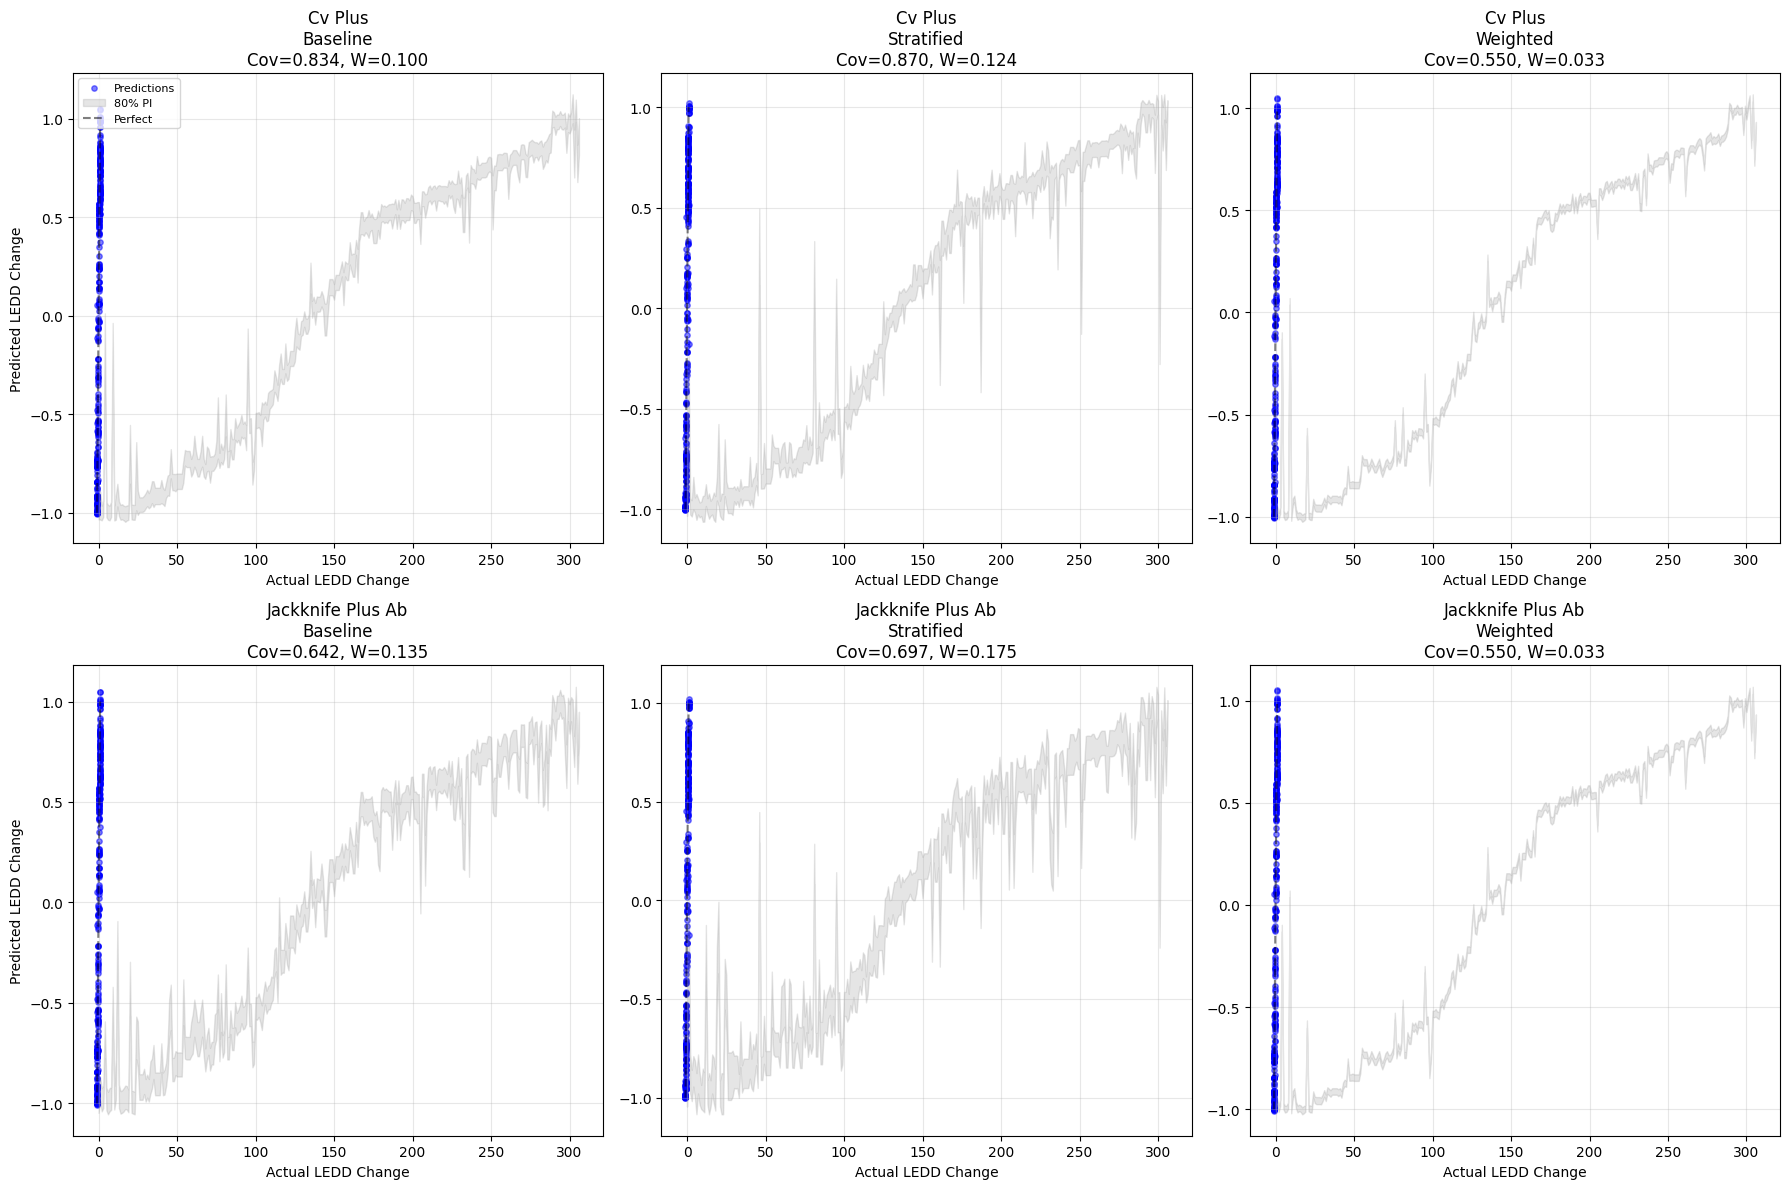

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8: VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("Creating visualizations...")
print("="*80)

# Main comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

conf_methods = ["cv_plus", "jackknife_plus_ab"]
approaches = [
    ('Baseline', results_baseline),
    ('Stratified', results_stratified),
    ('Weighted', results_weighted)
]

for i, conf_method in enumerate(conf_methods):
    for j, (approach_name, results) in enumerate(approaches):
        ax = axes[i, j]
        
        res = results[conf_method]
        y_test = y_test_2
        y_pred = res['y_pred']
        
        if 'y_pis' in res:
            y_lower = res['y_pis'][:, 0, 0]
            y_upper = res['y_pis'][:, 1, 0]
        else:
            y_lower = res['y_lower']
            y_upper = res['y_upper']
        
        # Sort for visualization
        sort_idx = np.argsort(y_test)
        y_test_sorted = y_test.values[sort_idx] if hasattr(y_test, 'values') else y_test[sort_idx]
        y_pred_sorted = y_pred[sort_idx]
        y_lower_sorted = y_lower[sort_idx]
        y_upper_sorted = y_upper[sort_idx]
        
        # Plot
        ax.scatter(y_test_sorted, y_pred_sorted, alpha=0.5, s=15, color='blue', label='Predictions')
        ax.fill_between(range(len(y_test_sorted)), y_lower_sorted, y_upper_sorted,
                         alpha=0.2, color='gray', label='80% PI')
        ax.plot([y_test_sorted.min(), y_test_sorted.max()],
                [y_test_sorted.min(), y_test_sorted.max()], 'k--', alpha=0.5, label='Perfect')
        
        ax.set_title(f'{conf_method.replace("_", " ").title()}\n{approach_name}\n'
                    f'Cov={res["coverage"]:.3f}, W={res["width"]:.3f}')
        ax.set_xlabel('Actual LEDD Change')
        if j == 0:
            ax.set_ylabel('Predicted LEDD Change')
        ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.plot()
# plt.savefig('cascade_uncertainty_NO_PROB_FILTER.png', dpi=300, bbox_inches='tight')


ANALYSIS COMPLETE!

Key files saved:
  - cascade_uncertainty_NO_PROB_FILTER.png
  - cascade_effect_by_uncertainty_bin.png

Key Results:
  Total patients in Stage 2: 1533
  VA uncertainty range: [0.0002, 0.1537]
  HIGH uncertainty patients: 372 (flagged, not excluded)


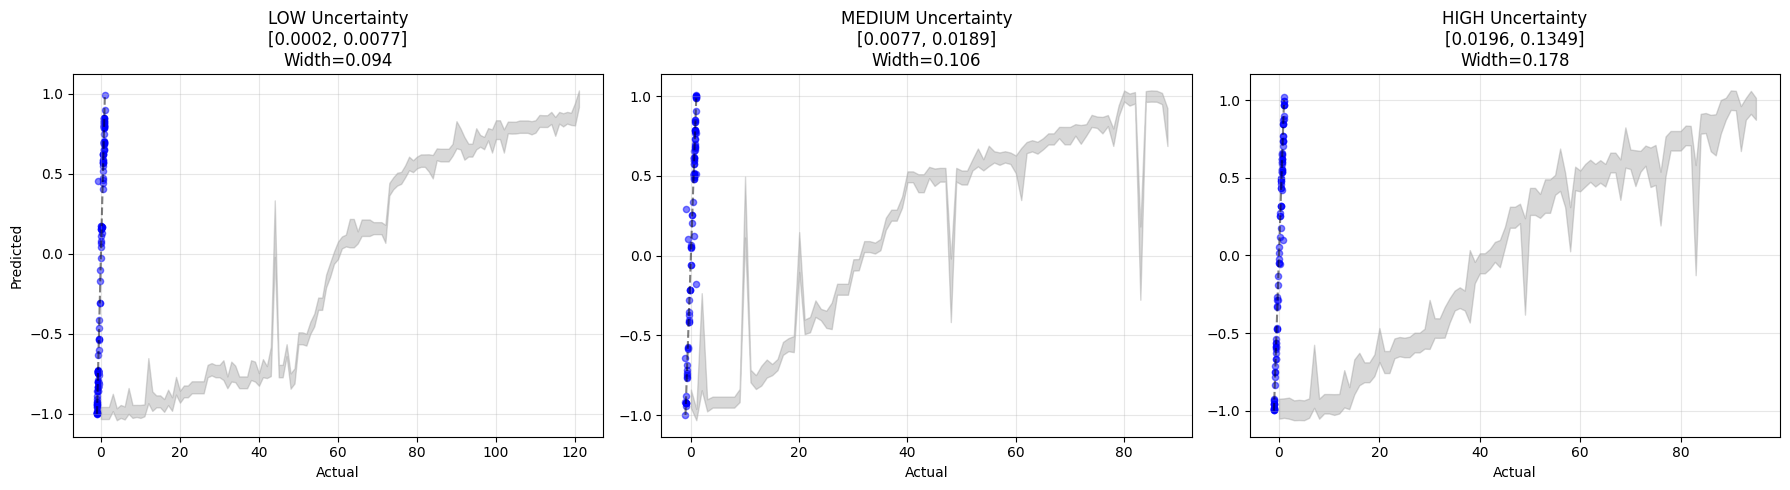

In [15]:
# CASCADE EFFECT by bin
if 'results_by_bin' in results_stratified['cv_plus']:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, bin_name in enumerate(['low', 'medium', 'high']):
        if bin_name not in results_stratified['cv_plus']['results_by_bin']:
            continue
            
        ax = axes[idx]
        
        # Get data for this bin
        mask = (bins_test == bin_name)
        y_test_bin = y_test_2[mask]
        y_pred_bin = results_stratified['cv_plus']['y_pred'][mask]
        y_lower_bin = results_stratified['cv_plus']['y_lower'][mask]
        y_upper_bin = results_stratified['cv_plus']['y_upper'][mask]
        
        # Sort
        sort_idx = np.argsort(y_test_bin)
        y_test_sorted = y_test_bin.values[sort_idx] if hasattr(y_test_bin, 'values') else y_test_bin[sort_idx]
        y_pred_sorted = y_pred_bin[sort_idx]
        y_lower_sorted = y_lower_bin[sort_idx]
        y_upper_sorted = y_upper_bin[sort_idx]
        
        # Plot
        ax.scatter(y_test_sorted, y_pred_sorted, alpha=0.5, s=20, color='blue')
        ax.fill_between(range(len(y_test_sorted)), y_lower_sorted, y_upper_sorted,
                         alpha=0.3, color='gray')
        ax.plot([y_test_sorted.min(), y_test_sorted.max()],
                [y_test_sorted.min(), y_test_sorted.max()], 'k--', alpha=0.5)
        
        bin_res = results_stratified['cv_plus']['results_by_bin'][bin_name]
        unc_range = va_unc_test_2[mask]
        
        ax.set_title(f'{bin_name.upper()} Uncertainty\n'
                    f'[{unc_range.min():.4f}, {unc_range.max():.4f}]\n'
                    f'Width={bin_res["width"]:.3f}')
        ax.set_xlabel('Actual')
        if idx == 0:
            ax.set_ylabel('Predicted')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.plot()
    # plt.savefig('cascade_effect_by_uncertainty_bin.png', dpi=300, bbox_inches='tight')
    # print("Saved: cascade_effect_by_uncertainty_bin.png")
    # plt.close()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nKey files saved:")
print("  - cascade_uncertainty_NO_PROB_FILTER.png")
print("  - cascade_effect_by_uncertainty_bin.png")
print("\nKey Results:")
print(f"  Total patients in Stage 2: {len(X_stage2)}")
print(f"  VA uncertainty range: [{va_uncertainty_stage2.min():.4f}, {va_uncertainty_stage2.max():.4f}]")
print(f"  HIGH uncertainty patients: {is_high_uncertainty.sum()} (flagged, not excluded)")